## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

sns.set_style("whitegrid")

## Load Dataset

In [2]:
df = pd.read_csv('../data/processed/featured_orders.csv')

print(df.shape)
df.head()

(96361, 38)


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,...,total_payment_value,customer_city,customer_state,customer_zip_code_prefix,review_score,has_review,review_comment_title,review_comment_message,review_creation_date,target
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,...,38.71,sao paulo,SP,3149,4.0,1,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,...,141.46,barreiras,BA,47813,4.0,1,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,...,179.12,vianopolis,GO,75265,5.0,1,NaN,NaN,2018-08-18 00:00:00,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,...,72.20,sao goncalo do amarante,RN,59296,5.0,1,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,...,28.62,santo andre,SP,9195,5.0,1,NaN,NaN,2018-02-17 00:00:00,1


## Dataset Information

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 96361 entries, 0 to 96360
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96361 non-null  str    
 1   customer_id                    96361 non-null  str    
 2   customer_unique_id             96361 non-null  str    
 3   order_status                   96361 non-null  str    
 4   order_purchase_timestamp       96361 non-null  str    
 5   order_approved_at              96361 non-null  str    
 6   order_delivered_carrier_date   96359 non-null  str    
 7   order_delivered_customer_date  96353 non-null  str    
 8   order_estimated_delivery_date  96361 non-null  str    
 9   delivery_days                  96353 non-null  float64
 10  delay_days                     96353 non-null  float64
 11  approval_time_hours            96361 non-null  float64
 12  purchase_year                  96361 non-null  int64  
 1

## Distribution of Review Scores

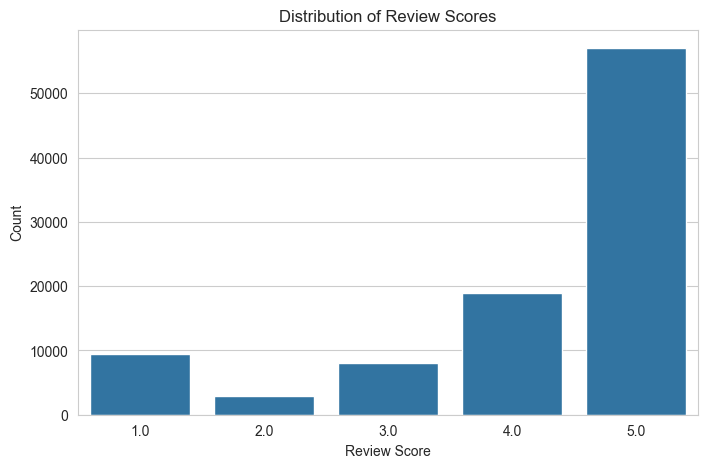

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(x='review_score', data=df)

plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Count')

plt.savefig('../images/review_distribution.png', bbox_inches='tight')
plt.show()

Insight
Most customers give high review scores.
Dataset may contain class imbalance.

## Positive vs Negative Reviews

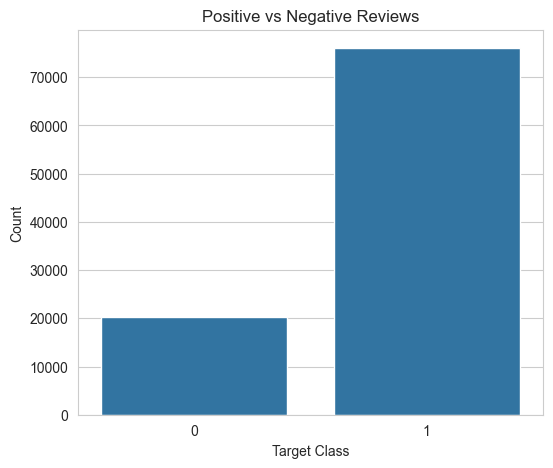

In [5]:
plt.figure(figsize=(6,5))

sns.countplot(x='target', data=df)

plt.title('Positive vs Negative Reviews')
plt.xlabel('Target Class')
plt.ylabel('Count')

plt.savefig('../images/target_distribution.png', bbox_inches='tight')
plt.show()

Target Definition
0 = Negative Review
1 = Positive Review

## Delivery Delay vs Review

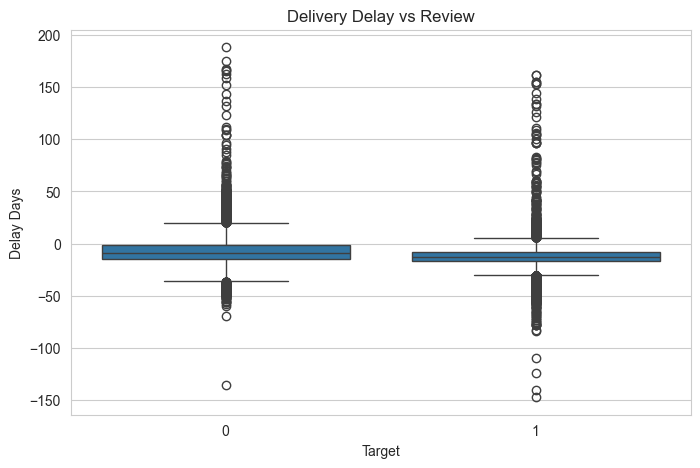

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='delay_days',
    data=df
)

plt.title('Delivery Delay vs Review')
plt.xlabel('Target')
plt.ylabel('Delay Days')

plt.show()

## Freight Ratio Distribution

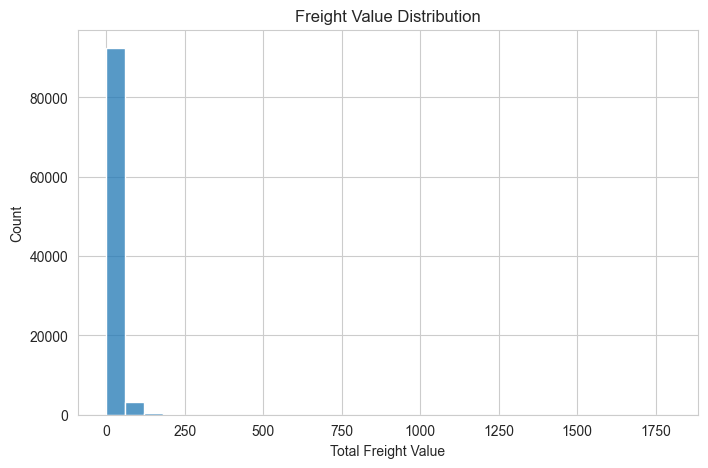

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['total_freight_value'], bins=30)

plt.title('Freight Value Distribution')
plt.xlabel('Total Freight Value')

plt.show()

Insight
High shipping costs may affect customer satisfaction.

## Correlation Heatmap

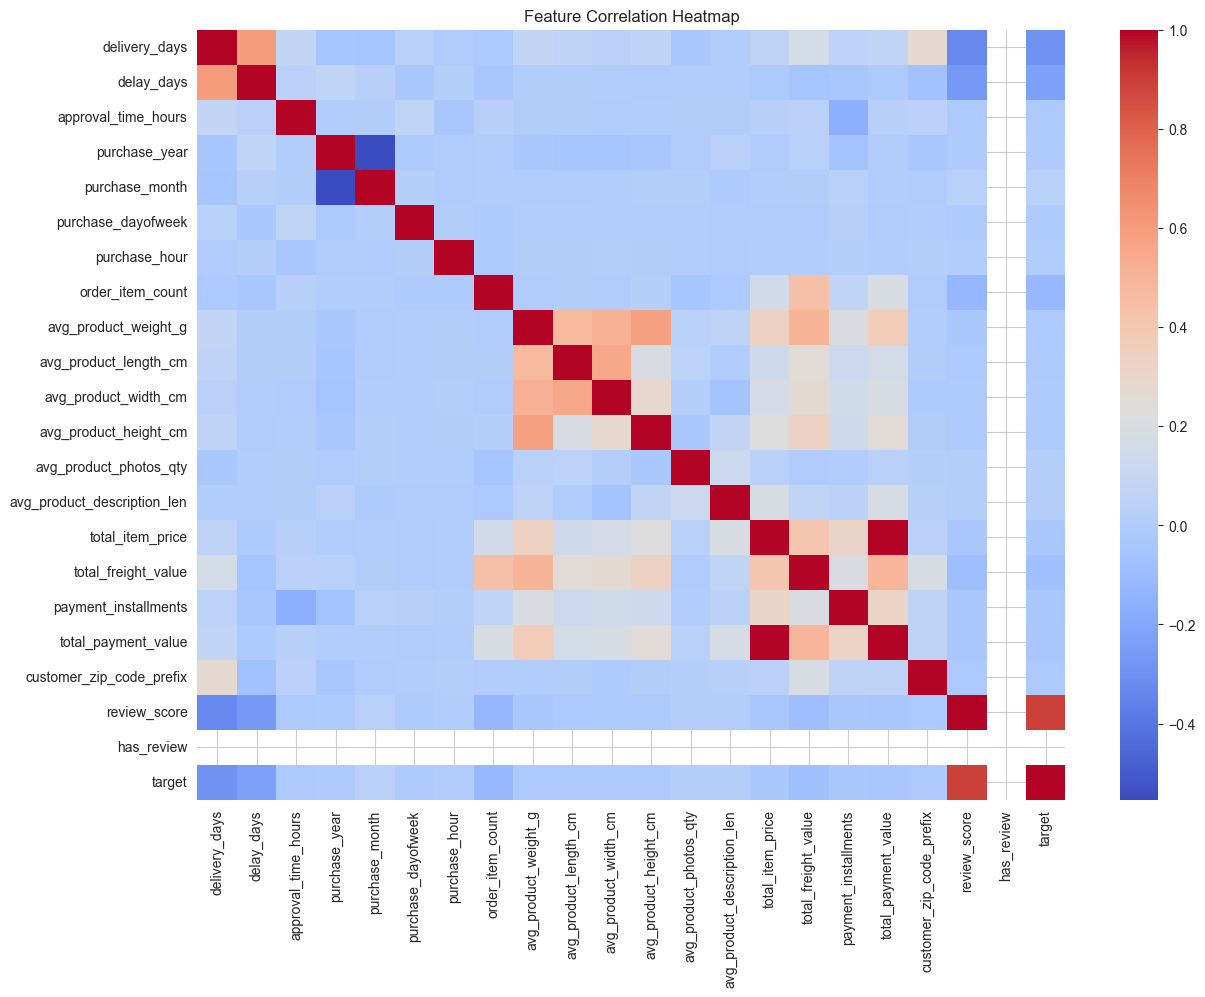

In [8]:
plt.figure(figsize=(14,10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

Insight
Identify relationships between operational features and customer satisfaction.

## Load Modeling Results

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Features and target
X = df.drop(columns=['target'])
y = df['target']

# Keep only numeric columns
X = X.select_dtypes(include=['int64', 'float64'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Random Forest model
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Probability predictions
y_prob = model.predict_proba(X_test)[:,1]

## Confusion Matrix

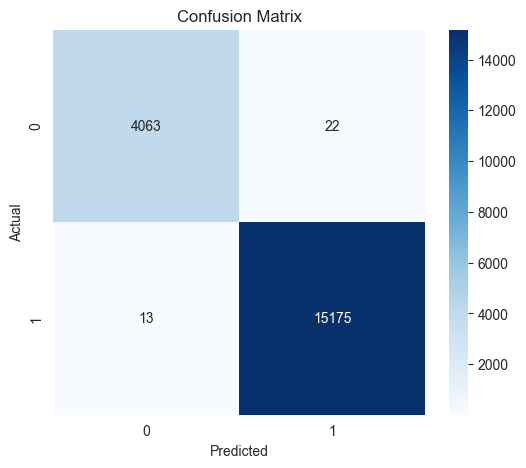

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.savefig('../images/confusion_matrix.png', bbox_inches='tight')
plt.show()

## Classification Report

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4085
           1       1.00      1.00      1.00     15188

    accuracy                           1.00     19273
   macro avg       1.00      1.00      1.00     19273
weighted avg       1.00      1.00      1.00     19273



## ROC Curve

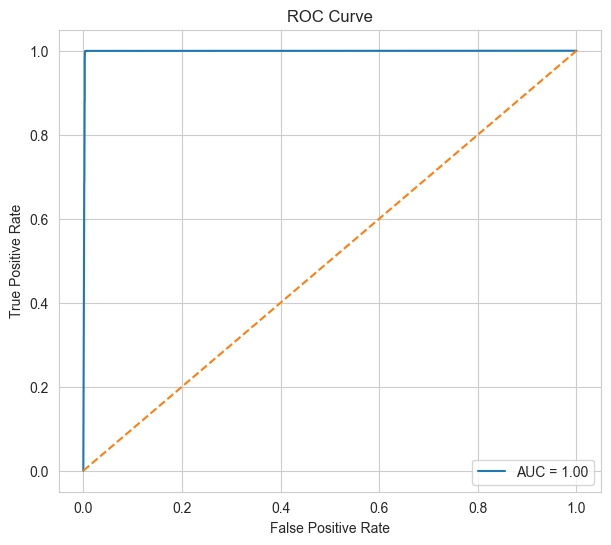

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig('../images/roc_curve.png', bbox_inches='tight')
plt.show()

## Model Comparison

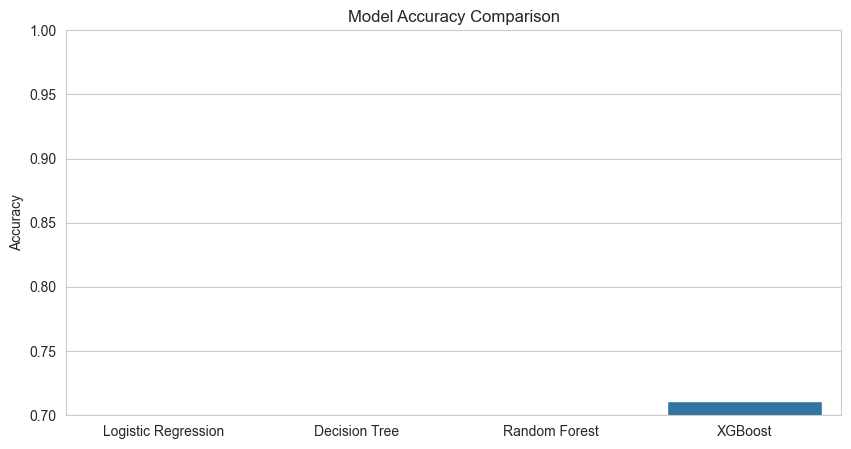

In [13]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

accuracy = [0.700000, 0.657368, 0.664737, 0.711053]

plt.figure(figsize=(10,5))

sns.barplot(x=models, y=accuracy)

plt.title('Model Accuracy Comparison')
plt.ylim(0.7, 1.0)
plt.ylabel('Accuracy')

plt.savefig('../images/model_comparison.png', bbox_inches='tight')
plt.show()

## Feature Importance

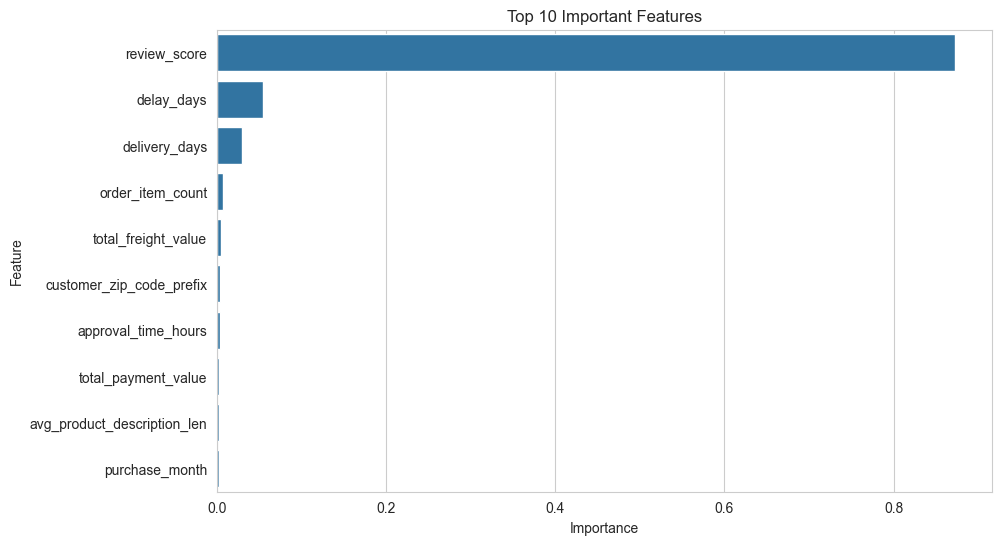

In [14]:
importance = model.feature_importances_
features = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feat_imp = feat_imp.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_imp.head(10)
)

plt.title('Top 10 Important Features')

plt.savefig('../images/feature_importance.png', bbox_inches='tight')
plt.show()

Insight

Top important features may include:

delivery_delay_days
waiting_days
freight_ratio
payment_installments

## Business Insights

Insight 1

Orders with higher delivery delays are more likely to receive negative reviews.

Insight 2

High freight costs relative to product price can reduce customer satisfaction.

Insight 3

Products with more photos and detailed descriptions tend to receive better reviews.

## Recommendations

Improve logistics for delayed orders.

Optimize shipping fees.

Encourage sellers to provide better product descriptions and images.

Use the model as an Early Warning System for customer dissatisfaction.

## Conclusion

The project successfully predicts customer satisfaction.

Machine Learning models can support proactive customer service.

The best model can help businesses reduce negative reviews.